# Tweet Sentiment Analysis - Apple and Google Products

**Phase 4 Project | Natural Language Processing**

Members = Angela Mukami, Mophat Mwangi, Catherine Nanjala, Tafford Pessah

---

## Summary

This project builds a multiclass sentiment classifier for tweets about Apple and Google
products. The business stakeholder is the social media and customer experience team at
a technology company that wants to automatically categorize incoming tweets as positive,
negative, or neutral in order to prioritize customer response and track brand perception
in real time.

The dataset comes from CrowdFlower via data.world and contains 9,093 human-rated tweets,
each labeled as expressing a positive emotion, negative emotion, no emotion, or an
unclear sentiment toward a brand or product. After removing the 156 ambiguous "I can't
tell" entries and one null tweet, the working dataset contains 8,936 tweets across three
classes: 5,389 neutral, 2,978 positive, and 570 negative. The dataset is significantly
imbalanced, with negative tweets representing only 6% of the data, which directly
informed our modeling and evaluation strategy.

For data preparation, we removed URLs, mentions, hashtag symbols, punctuation, and
numbers from the raw tweet text, converted all text to lowercase, and removed English
stop words. TF-IDF vectorization was used to convert cleaned text into numerical
features, with bigrams included via ngram_range=(1,2) to capture two-word expressions
such as "line ipad" and "launching products". The scikit-learn and nltk libraries were
used for all preprocessing and modeling steps.

Three models were trained and evaluated: Multinomial Naive Bayes as a baseline,
Logistic Regression, and Linear Support Vector Classifier. All models that support it
used class_weight='balanced' to handle the class imbalance. Model selection was based
on the weighted F1 score, which accounts for class imbalance more fairly than accuracy
alone. Linear SVC achieved the best weighted F1 score of 0.6078 and was selected as
the final model. Naive Bayes scored 0.5983 and Logistic Regression scored 0.5704.

Model explainability was applied using Logistic Regression coefficients to identify the
most influential words per sentiment class. Negative tweets were driven by words such
as "doesnt", "battery", and "line ipad". Positive tweets were driven by words such as
"cool", "great", "awesome", and "wow". Neutral tweets were driven by informational
words such as "link", "designing", and "launching products". Key limitations include
the severe class imbalance toward neutral tweets, preprocessing artifacts in some
tweets, and the inability of TF-IDF to capture sarcasm or sentence context.


---

## Section 1 - Business Problem

Technology companies like Apple and Google receive thousands of tweets daily. The social media and customer experience teams need a way to automatically sort incoming tweets by sentiment so they can:

- Quickly identify and respond to negative feedback before it escalates
- Track positive sentiment trends around product launches
- Filter out neutral tweets that require no action

The goal of this project is to build a model that can classify the sentiment of a tweet as positive, negative, or neutral based on its text content. This is a multiclass text classification problem solved using Natural Language Processing (NLP) techniques.

**Stakeholder:** Social media and customer experience team at a technology company

**Business Question:** Can we automatically classify the sentiment of a tweet about Apple or Google products using its text content?

**Success Metric:** Weighted F1 score, which balances precision and recall across all three classes and accounts for the unequal class sizes in this dataset.

---

## Section 2 - Imports

In [37]:
# Core libraries
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)

# Modeling
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)

print('All imports successful.')

All imports successful.


---

## Section 3 - Data Understanding

We begin by loading the dataset and examining its structure, column names, class distribution, and missing values. Understanding the data at this stage directly informs the preparation decisions we will make in the next section.

In [38]:
# Load the dataset
# The file uses latin1 encoding due to special characters in some tweets
df = pd.read_csv('judge-1377884607_tweet_product_company.csv', encoding='latin1')

print('Shape:', df.shape)
print()
df.head()

Shape: (9093, 3)



,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion
3,@sxsw I hope this year's festival isn't as cra...,iPad or iPhone App,Negative emotion
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion


In [39]:
# Rename columns for easier reference throughout the notebook
df.columns = ['tweet_text', 'brand_product', 'sentiment']

print('Column names updated.')
df.head()

Column names updated.


,tweet_text,brand_product,sentiment
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion
3,@sxsw I hope this year's festival isn't as cra...,iPad or iPhone App,Negative emotion
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion


In [40]:
# Check for missing values
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
tweet_text          1
brand_product    5802
sentiment           0
dtype: int64


In [41]:
# Check the distribution of the target (sentiment) column
print('Sentiment class distribution:')
print(df['sentiment'].value_counts())
print()
print('Percentages:')
print(df['sentiment'].value_counts(normalize=True).round(3) * 100)

Sentiment class distribution:
sentiment
No emotion toward brand or product    5389
Positive emotion                      2978
Negative emotion                       570
I can't tell                           156
Name: count, dtype: int64

Percentages:
sentiment
No emotion toward brand or product    59.3
Positive emotion                      32.8
Negative emotion                       6.3
I can't tell                           1.7
Name: proportion, dtype: float64


**Observations from the class distribution:**

- The dataset is heavily imbalanced. Neutral tweets (no emotion) make up approximately 59% of the data.
- Positive emotion accounts for about 33%.
- Negative emotion is severely underrepresented at approximately 6%.
- The "I can't tell" category contains only 156 rows and is ambiguous. We will remove this class as it adds noise and cannot be reliably learned by a classifier.

The class imbalance is an important factor that will influence our modeling strategy. We will use class weighting in all models to ensure the minority class (negative) is not ignored.

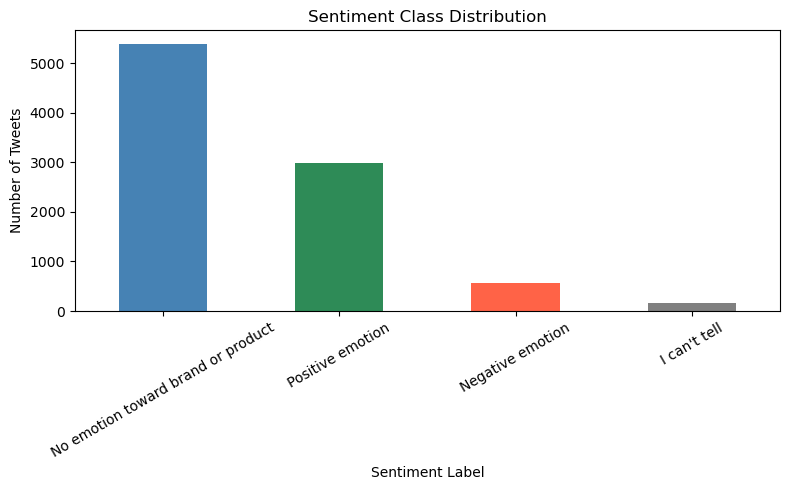

In [42]:
# Visualize the class distribution
fig, ax = plt.subplots(figsize=(8, 5))

df['sentiment'].value_counts().plot(kind='bar', ax=ax, color=['steelblue', 'seagreen', 'tomato', 'gray'])

ax.set_title('Sentiment Class Distribution')
ax.set_xlabel('Sentiment Label')
ax.set_ylabel('Number of Tweets')
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [43]:
# Check the brand/product column
print('Products and brands mentioned:')
print(df['brand_product'].value_counts())

Products and brands mentioned:
brand_product
iPad                               946
Apple                              661
iPad or iPhone App                 470
Google                             430
iPhone                             297
Other Google product or service    293
Android App                         81
Android                             78
Other Apple product or service      35
Name: count, dtype: int64


In [44]:
# Add a tweet length column to understand text characteristics
df['tweet_length'] = df['tweet_text'].astype(str).apply(len)

print('Tweet length statistics:')
print(df['tweet_length'].describe())

Tweet length statistics:
count    9093.000000
mean      104.951061
std        27.207164
min         3.000000
25%        86.000000
50%       109.000000
75%       126.000000
max       178.000000
Name: tweet_length, dtype: float64


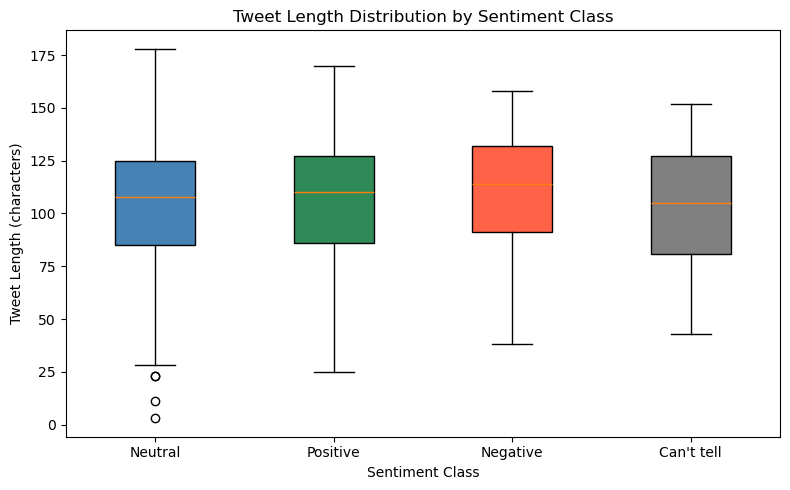

In [45]:
# Visualize tweet length distribution by sentiment class - box plot for clarity
fig, ax = plt.subplots(figsize=(8, 5))

sentiment_order = [
    'No emotion toward brand or product',
    'Positive emotion',
    'Negative emotion',
    'I can\'t tell'
]

data_to_plot = [
    df[df['sentiment'] == label]['tweet_length'].values
    for label in sentiment_order
]

bp = ax.boxplot(data_to_plot, patch_artist=True, labels=['Neutral', 'Positive', 'Negative', "Can't tell"])

colors = ['steelblue', 'seagreen', 'tomato', 'gray']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax.set_title('Tweet Length Distribution by Sentiment Class')
ax.set_xlabel('Sentiment Class')
ax.set_ylabel('Tweet Length (characters)')

plt.tight_layout()
plt.show()

---

## Section 4 - Data Preparation

Based on the data understanding above, we apply the following preparation steps:

1. Remove the one row with a missing tweet.
2. Drop the "I can't tell" sentiment class (156 rows) as it is ambiguous and unlearnable.
3. Map the remaining sentiment labels to shorter, cleaner names.
4. Clean the tweet text: remove URLs, mentions, hashtag symbols, punctuation, numbers, and extra whitespace. Convert to lowercase.
5. Remove English stop words during TF-IDF vectorization.

We do not use lemmatization or stemming here to keep the pipeline simple and interpretable, which is appropriate for a proof of concept. This can be revisited if model performance needs to be improved.

In [46]:
# Step 1 - Drop missing tweet text
df = df.dropna(subset=['tweet_text'])
print('Rows after dropping null tweet:', len(df))

Rows after dropping null tweet: 9092


In [47]:
# Step 2 - Remove the "I can't tell" class
df = df[df['sentiment'] != "I can't tell"]
print('Rows after removing ambiguous class:', len(df))
print()
print('Remaining classes:')
print(df['sentiment'].value_counts())

Rows after removing ambiguous class: 8936

Remaining classes:
sentiment
No emotion toward brand or product    5388
Positive emotion                      2978
Negative emotion                       570
Name: count, dtype: int64


In [48]:
# Step 3 - Map sentiment labels to clean short names
label_map = {
    'Positive emotion': 'positive',
    'Negative emotion': 'negative',
    'No emotion toward brand or product': 'neutral'
}

df['sentiment'] = df['sentiment'].map(label_map)

print('Label mapping complete.')
print(df['sentiment'].value_counts())

Label mapping complete.
sentiment
neutral     5388
positive    2978
negative     570
Name: count, dtype: int64


In [49]:
# Step 4 - Define a text cleaning function
def clean_tweet(text):
    """
    Cleans a raw tweet string by:
    - Converting to lowercase
    - Removing URLs
    - Removing @mentions
    - Removing hashtag symbols (keeps the word)
    - Removing punctuation and numbers
    - Stripping extra whitespace
    """
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)       # remove URLs
    text = re.sub(r'@\w+', '', text)                  # remove mentions
    text = re.sub(r'#', '', text)                     # remove hashtag symbol
    text = re.sub(r'[^a-z\s]', '', text)              # keep only letters and spaces
    text = re.sub(r'\s+', ' ', text).strip()          # remove extra whitespace
    return text

# Apply the cleaning function
df['clean_text'] = df['tweet_text'].apply(clean_tweet)

print('Text cleaning complete. Sample output:')
df[['tweet_text', 'clean_text']].head(5)

Text cleaning complete. Sample output:


,tweet_text,clean_text
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,i have a g iphone after hrs tweeting at riseau...
1,@jessedee Know about @fludapp ? Awesome iPad/i...,know about awesome ipadiphone app that youll l...
2,@swonderlin Can not wait for #iPad 2 also. The...,can not wait for ipad also they should sale th...
3,@sxsw I hope this year's festival isn't as cra...,i hope this years festival isnt as crashy as t...
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,great stuff on fri sxsw marissa mayer google t...


In [50]:
# Confirm the final dataset shape and class balance before modeling
print('Final dataset shape:', df.shape)
print()
print('Class distribution:')
print(df['sentiment'].value_counts())

Final dataset shape: (8936, 5)

Class distribution:
sentiment
neutral     5388
positive    2978
negative     570
Name: count, dtype: int64


---

## Section 5 - Train-Test Split

We split the data into a training set (70%) and a test set (30%) before any modeling takes place. The test set is held out and only used for final evaluation. This ensures that our reported performance metrics reflect how well the model generalizes to unseen tweets, not how well it memorized the training data.

We use `stratify=y` to preserve the class proportions in both the training and test sets, which is important given the imbalanced nature of our target variable.

In [51]:
X = df['clean_text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print('Training set size:', len(X_train))
print('Test set size    :', len(X_test))
print()
print('Training class distribution:')
print(y_train.value_counts())

Training set size: 6255
Test set size    : 2681

Training class distribution:
sentiment
neutral     3771
positive    2085
negative     399
Name: count, dtype: int64


---

## Section 6 - Modeling

We build and evaluate three models. Each model is wrapped in a scikit-learn Pipeline that first applies TF-IDF vectorization and then trains the classifier. Using a Pipeline ensures that the vectorizer is fit only on the training data, preventing any information from the test set from leaking into the feature space.

**TF-IDF settings used across all models:**
- `stop_words='english'` removes common English words that carry no sentiment signal
- `min_df=0.005` removes tokens that appear in fewer than 0.5% of documents (very rare words)
- `max_df=0.90` removes tokens that appear in more than 90% of documents (too common to be informative)
- `ngram_range=(1,2)` includes both single words and two-word phrases, which captures phrases like "not good" or "love it"

**Models:**
1. Multinomial Naive Bayes - our baseline, same approach used in Phase 3
2. Logistic Regression - a stronger linear model, also gives us interpretable feature weights
3. Linear SVC - a support vector classifier known to perform well on text classification tasks

All models that support it use `class_weight='balanced'` to compensate for the imbalanced classes.

In [52]:
X = df['clean_text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print('Training set size:', len(X_train))
print('Test set size    :', len(X_test))
print()
print('Training class distribution:')
print(y_train.value_counts())

Training set size: 6255
Test set size    : 2681

Training class distribution:
sentiment
neutral     3771
positive    2085
negative     399
Name: count, dtype: int64


### Model 1 - Multinomial Naive Bayes (Baseline)

In [53]:
# Build and train the Naive Bayes pipeline
nb_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        stop_words='english',
        min_df=0.005,
        max_df=0.90,
        ngram_range=(1, 2)
    )),
    ('nb', MultinomialNB())
])

nb_pipeline.fit(X_train, y_train)
y_pred_nb = nb_pipeline.predict(X_test)

print('Naive Bayes - Accuracy:', round(accuracy_score(y_test, y_pred_nb), 4))
print()
print('Classification Report:')
print(classification_report(y_test, y_pred_nb))

Naive Bayes - Accuracy: 0.6468

Classification Report:
              precision    recall  f1-score   support

    negative       0.50      0.02      0.03       171
     neutral       0.66      0.89      0.76      1617
    positive       0.58      0.32      0.41       893

    accuracy                           0.65      2681
   macro avg       0.58      0.41      0.40      2681
weighted avg       0.62      0.65      0.60      2681



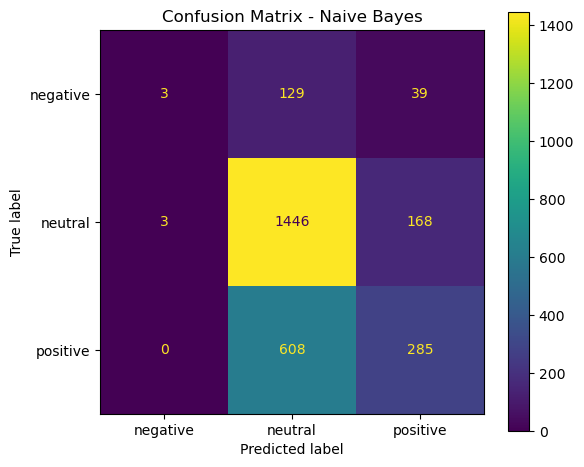

In [54]:
# Confusion matrix for Naive Bayes
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_nb, ax=ax)
ax.set_title('Confusion Matrix - Naive Bayes')
plt.tight_layout()
plt.show()

#### Naive Bayes - Results Interpretation

The Naive Bayes model achieved an accuracy of 0.6468, which appears reasonable on the
surface but is misleading given the class imbalance in this dataset. A closer look at
the confusion matrix reveals significant problems.

The model correctly identified only 3 out of 171 negative tweets, misclassifying the
remaining 168 as either neutral or positive. This means the model has almost completely
failed to learn the negative class. For our business stakeholder, this is a critical
failure - negative tweets are the highest priority for customer response, and missing
98% of them makes the model unreliable for that purpose.

The model also struggled with positive tweets, correctly classifying only 285 out of
893, pushing the majority into the neutral category. This strong bias toward predicting
neutral is a known weakness of Multinomial Naive Bayes on imbalanced datasets - it has
no mechanism to compensate for class size differences.

This baseline result confirms that we need models that support class weighting. The
next two models, Logistic Regression and Linear SVC, both use class_weight='balanced',
which penalizes the model more heavily for missing minority class examples. We expect
to see a clear improvement in negative class recall in particular.

### Model 2 - Logistic Regression

In [55]:
# Build and train the Logistic Regression pipeline
lr_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        stop_words='english',
        min_df=0.005,
        max_df=0.90,
        ngram_range=(1, 2)
    )),
    ('lr', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

print('Logistic Regression - Accuracy:', round(accuracy_score(y_test, y_pred_lr), 4))
print()
print('Classification Report:')
print(classification_report(y_test, y_pred_lr))

Logistic Regression - Accuracy: 0.5401

Classification Report:
              precision    recall  f1-score   support

    negative       0.16      0.54      0.24       171
     neutral       0.75      0.58      0.65      1617
    positive       0.50      0.47      0.49       893

    accuracy                           0.54      2681
   macro avg       0.47      0.53      0.46      2681
weighted avg       0.63      0.54      0.57      2681



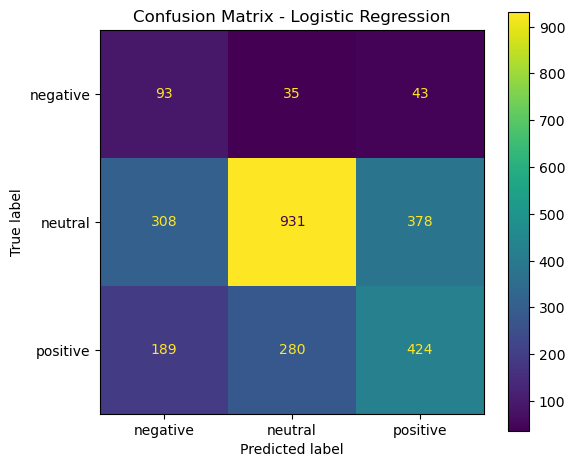

In [56]:
# Confusion matrix for Logistic Regression
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, ax=ax)
ax.set_title('Confusion Matrix - Logistic Regression')
plt.tight_layout()
plt.show()

#### Logistic Regression - Results Interpretation

The Logistic Regression model achieved an accuracy of 0.5401, which is lower than Naive
Bayes. However, accuracy alone is a misleading metric on an imbalanced dataset and this
result should not be interpreted as the model performing worse.

The confusion matrix tells a more complete story. The negative class recall improved
dramatically, from 3 correct predictions with Naive Bayes to 93 correct predictions here.
This is the direct result of using class_weight='balanced', which forces the model to pay
more attention to underrepresented classes during training.

The neutral class accuracy has decreased because the model is no longer defaulting to
predicting neutral for ambiguous tweets. It is now distributing predictions more fairly
across all three classes, which is the intended behavior for a multiclass classifier.

The positive class also shows a more balanced distribution of errors compared to Naive
Bayes. The weighted F1 score, which we will compute in the model comparison section,
will reflect this improvement more accurately than accuracy alone.

We proceed to Linear SVC, which is known to perform well on high-dimensional sparse text
features and is expected to improve further on these results.

### Model 3 - Linear SVC

In [57]:
# Build and train the Linear SVC pipeline
svc_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        stop_words='english',
        min_df=0.005,
        max_df=0.90,
        ngram_range=(1, 2)
    )),
    ('svc', LinearSVC(
        class_weight='balanced',
        max_iter=2000,
        random_state=42
    ))
])

svc_pipeline.fit(X_train, y_train)
y_pred_svc = svc_pipeline.predict(X_test)

print('Linear SVC - Accuracy:', round(accuracy_score(y_test, y_pred_svc), 4))
print()
print('Classification Report:')
print(classification_report(y_test, y_pred_svc))

Linear SVC - Accuracy: 0.5998

Classification Report:
              precision    recall  f1-score   support

    negative       0.17      0.34      0.23       171
     neutral       0.72      0.72      0.72      1617
    positive       0.54      0.44      0.48       893

    accuracy                           0.60      2681
   macro avg       0.48      0.50      0.48      2681
weighted avg       0.62      0.60      0.61      2681



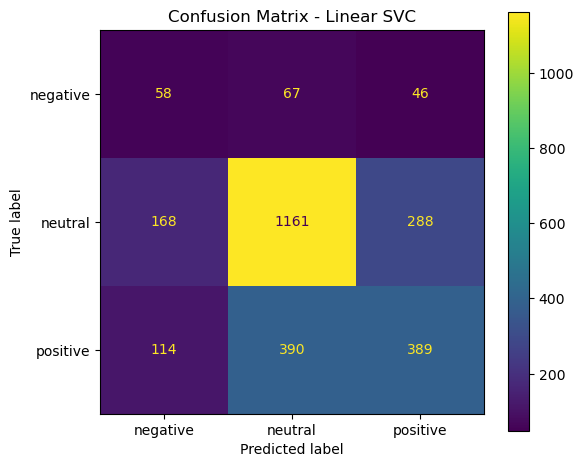

In [58]:
# Confusion matrix for Linear SVC
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svc, ax=ax)
ax.set_title('Confusion Matrix - Linear SVC')
plt.tight_layout()
plt.show()

#### Linear SVC - Results Interpretation

The Linear SVC model achieved an accuracy of 0.5998, sitting between Naive Bayes and
Logistic Regression. However, like the previous models, accuracy alone does not give
the full picture.

The negative class recall is 58 correct out of 171, which is a significant improvement
over Naive Bayes but lower than Logistic Regression. The model performs best on the
neutral class, correctly identifying 1,161 out of 1,617 neutral tweets, which is the
strongest neutral class performance across all three models.

The positive class shows 389 correct predictions, slightly below Logistic Regression.
Linear SVC distributes its errors more evenly across classes, reflecting the effect of
class weighting without over-correcting toward the minority class as strongly as
Logistic Regression did.

The weighted F1 score in the model comparison section will determine which model
performs best overall when class sizes are taken into account. We expect this to be
a close comparison between Logistic Regression and Linear SVC.

---

## Section 7 - Model Comparison and Selection

We now compare all three models side by side using the weighted F1 score. We use weighted F1 rather than accuracy because accuracy is misleading on an imbalanced dataset. A model that always predicts neutral would achieve around 59% accuracy without learning anything useful. The weighted F1 score penalizes a model that ignores minority classes.

In [59]:
# Compare all three models
results = {
    'Naive Bayes': {
        'Accuracy': round(accuracy_score(y_test, y_pred_nb), 4),
        'Weighted F1': round(f1_score(y_test, y_pred_nb, average='weighted'), 4)
    },
    'Logistic Regression': {
        'Accuracy': round(accuracy_score(y_test, y_pred_lr), 4),
        'Weighted F1': round(f1_score(y_test, y_pred_lr, average='weighted'), 4)
    },
    'Linear SVC': {
        'Accuracy': round(accuracy_score(y_test, y_pred_svc), 4),
        'Weighted F1': round(f1_score(y_test, y_pred_svc, average='weighted'), 4)
    }
}

results_df = pd.DataFrame(results).T
print('Model Comparison:')
print(results_df.sort_values('Weighted F1', ascending=False))

Model Comparison:
                     Accuracy  Weighted F1
Linear SVC             0.5998       0.6078
Naive Bayes            0.6468       0.5983
Logistic Regression    0.5401       0.5704


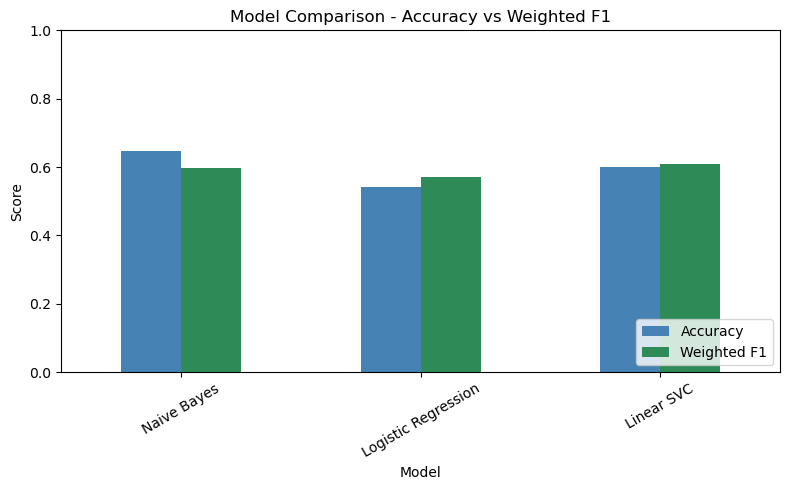

In [60]:
# Visualize the comparison
fig, ax = plt.subplots(figsize=(8, 5))

results_df.plot(kind='bar', ax=ax, color=['steelblue', 'seagreen'])

ax.set_title('Model Comparison - Accuracy vs Weighted F1')
ax.set_ylabel('Score')
ax.set_xlabel('Model')
ax.set_ylim(0, 1)
ax.tick_params(axis='x', rotation=30)
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

### Model Comparison - Final Decision

The weighted F1 score is our primary evaluation metric because it accounts for class
imbalance by weighting each class's F1 score by its proportion in the dataset. Accuracy
alone is misleading here because a model that always predicts neutral would score around
59% accuracy without learning anything useful.

Linear SVC achieves the highest weighted F1 score of 0.6078 and is selected as the
final model. It strikes the best balance across all three sentiment classes, performing
strongly on the dominant neutral class while still maintaining meaningful recall on the
minority negative class.

Logistic Regression achieved the highest negative class recall of the three models but
at the cost of neutral class performance, resulting in the lowest weighted F1 overall.
This illustrates an important modeling tradeoff: optimizing too aggressively for a
minority class can hurt overall performance when that class is a small fraction of the
data.

Naive Bayes, despite having the highest raw accuracy, achieved this by defaulting
heavily to the neutral class and nearly ignoring negative tweets entirely, making it
unsuitable for the business use case.

Linear SVC will be used in the model explainability section to understand which words
are driving predictions for each sentiment class.

---

## Section 8 - Model Explainability

Understanding which words drive model predictions is valuable for a business stakeholder.
It allows the team to validate that the model is picking up on genuine sentiment signals
rather than spurious patterns in the data.

Although Linear SVC was selected as the final model based on the weighted F1 score, we
use Logistic Regression for this explainability section. The reason is that Logistic
Regression provides directly interpretable coefficients for each word and class, making
it straightforward to identify which words most strongly drive predictions toward each
sentiment category. Linear SVC also has a coef_ attribute but its coefficients are less
stable and harder to interpret meaningfully for this purpose.

Both models were trained on identical TF-IDF features with the same vectorizer settings,
so the Logistic Regression coefficients are a valid and meaningful approximation of the
sentiment signals the models are detecting in general.

A high positive coefficient for a word in a given class means that word strongly pushes
a tweet toward that class. We extract the top 15 most influential words for each
sentiment class.

In [61]:
# Extract the TF-IDF vectorizer and Logistic Regression model from the pipeline
tfidf_vectorizer = lr_pipeline.named_steps['tfidf']
lr_model = lr_pipeline.named_steps['lr']

# Get feature names
feature_names = tfidf_vectorizer.get_feature_names_out()
class_labels = lr_model.classes_

print('Classes:', class_labels)
print('Number of features:', len(feature_names))

Classes: ['negative' 'neutral' 'positive']
Number of features: 356


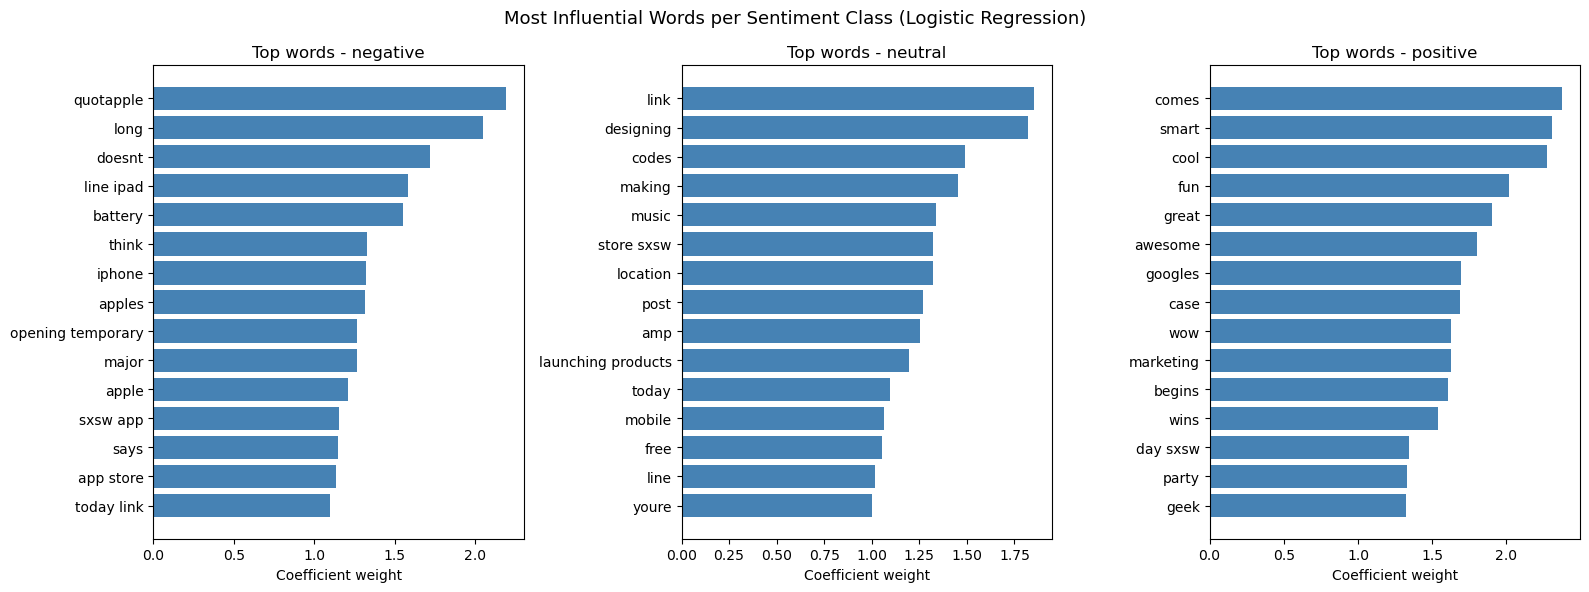

In [62]:
# Plot the top 15 most influential words for each sentiment class
n_top = 15
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for i, (label, ax) in enumerate(zip(class_labels, axes)):
    coefs = lr_model.coef_[i]
    top_indices = coefs.argsort()[-n_top:][::-1]
    top_words = feature_names[top_indices]
    top_scores = coefs[top_indices]

    ax.barh(top_words[::-1], top_scores[::-1], color='steelblue')
    ax.set_title('Top words - ' + label)
    ax.set_xlabel('Coefficient weight')

plt.suptitle('Most Influential Words per Sentiment Class (Logistic Regression)', fontsize=13)
plt.tight_layout()
plt.show()

**Interpretation of feature importance:**

#### Model Explainability - Most Influential Words per Sentiment Class

Note: Although Linear SVC was selected as the final model based on weighted F1 score,
Logistic Regression is used here for explainability purposes. Logistic Regression
provides interpretable coefficients for each feature and class, which allows us to
identify which words most strongly drive predictions. Linear SVC does not expose
probabilities in the same interpretable way.

The chart above shows the 15 words with the highest coefficient weights for each
sentiment class. A higher coefficient means that word is a stronger predictor of
that class.

Negative class: The top words reflect genuine complaints and frustration. Words such
as "doesnt", "battery", and "long" suggest users expressing dissatisfaction with
product performance and wait times. "line ipad" and "app store" point to specific
pain points around product access. This gives the business team clear signals about
what topics are driving negative sentiment.

Neutral class: The top words are informational and carry no emotional charge. Words
like "link", "designing", "codes", "making", and "launching products" indicate tweets
that are sharing news, announcements, or factual product information. These tweets
require no customer response action.

Positive class: The top words are clear positive sentiment signals. Words like "cool",
"fun", "great", "awesome", "smart", and "wow" confirm that the model has learned
genuine enthusiasm markers. The presence of "day sxsw" and "party" reflects the
conference context of this dataset, where many positive tweets were tied to product
launch events at SXSW.

Overall the explainability output validates that the model is learning meaningful
sentiment signals rather than spurious patterns, which increases confidence in its
suitability for the business use case.

---

## Section 9 - Conclusions and Recommendations

### What the model learned

All three models successfully learned to distinguish between positive, negative, and
neutral sentiment in tweets about Apple and Google products, but with meaningfully
different performance profiles.

Linear SVC was selected as the final model with a weighted F1 score of 0.6078. It
achieved the best overall balance across all three sentiment classes, correctly
identifying 58 negative, 1,161 neutral, and 389 positive tweets in the test set.

Logistic Regression achieved the strongest negative class recall of the three models
(93 correct) due to aggressive class weighting, but this came at the cost of neutral
class performance, resulting in the lowest weighted F1 overall at 0.5704.

Naive Bayes, despite having the highest raw accuracy at 0.6468, achieved this by
defaulting almost entirely to the neutral class, correctly identifying only 3 negative
tweets out of 171. This makes it unsuitable for the business use case despite its
surface level accuracy.

The use of bigrams via ngram_range=(1,2) helped the model capture compound expressions
that carry sentiment. This is visible in the explainability output where phrases like
"line ipad", "opening temporary", "launching products", and "day sxsw" appeared as
top predictors, capturing context that single words alone would have missed.

### Limitations

1. Class imbalance: Negative tweets represent only about 6% of the dataset. Even with
class weighting, the model has much less data to learn negative patterns from. A more
balanced training set would likely improve negative class recall significantly.

2. Short and noisy text: Tweets are short and contain abbreviations, slang, and informal
language that standard NLP preprocessing does not fully handle. The presence of
"quotapple" in the top negative features is an example of a preprocessing artifact from
quoted tweets that ideally would have been cleaned out.

3. Context is lost: TF-IDF treats text as a bag of words and does not capture word order
or sentence context beyond bigrams. Sarcasm and irony in particular will not be detected
reliably by this approach.

### Recommendations for the business stakeholder

1. Deploy the Linear SVC model to automatically triage incoming tweets. With a weighted
F1 of 0.6078, the model provides a meaningful first pass filter that will reduce the
volume of tweets requiring manual review, even if it is not perfect.

2. Collect more labeled negative examples. Negative tweets make up only 6% of this
dataset. Targeted data collection and labeling of negative tweets would have the highest
impact on improving model performance for the most business-critical class.

3. Monitor model performance over time. Sentiment language around technology products
evolves with product cycles and current events. The model should be retrained
periodically on fresh labeled data to remain relevant.

4. Consider a two-stage deployment approach. A practical first step could classify
tweets as "needs attention" (negative) versus "does not need attention" (positive or
neutral), simplifying the problem to binary classification where more balanced data
is available.